Nuestro objetivo es analizar y extraer información valiosa y estrategica de la base de datos NorthWind.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pathlib import Path
import seaborn as sbn

In [2]:
BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "northwind.db"

conn = sqlite3.connect(DB_PATH)

Creamos la conexión con la base de datos NorthWind.

In [13]:
#Clientes
query1 = '''
         SELECT c.CustomerName AS NombreCliente, SUM(od.Quantity) as UnidadesVendidas, sum(od.Quantity * p.Price) AS Monto FROM Customers c
        JOIN Orders o ON c.CustomerID = o.CustomerID
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products P ON od.ProductID = p.ProductID
        GROUP BY c.CustomerName
        ORDER BY Monto DESC
        '''
clientes_ventas = pd.read_sql_query(query1, conn)
print(clientes_ventas)

                         NombreCliente  UnidadesVendidas     Monto
0                         Ernst Handel              1418  35631.21
1                       Mère Paillarde               422  23362.60
2                   Save-a-lot Markets               775  22500.06
3           Rattlesnake Canyon Grocery               573  18421.42
4                           QUICK-Stop               839  18178.80
..                                 ...               ...       ...
69              Océano Atlántico Ltda.                24    399.00
70                     Du monde entier                13    336.00
71          Centro comercial Moctezuma                11    126.00
72  Ana Trujillo Emparedados y helados                 6    111.00
73                      Franchi S.p.A.                 2     62.46

[74 rows x 3 columns]


Se hizo una consulta a la base de datos para ver el monto en ventas por cliente y la cantidad de unidades que han comprado.

In [14]:
print(clientes_ventas.info())
print(clientes_ventas.duplicated(subset=['NombreCliente']).any())
print(clientes_ventas.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   NombreCliente     74 non-null     object 
 1   UnidadesVendidas  74 non-null     int64  
 2   Monto             74 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ KB
None
False
NombreCliente       0
UnidadesVendidas    0
Monto               0
dtype: int64


No hay registros duplicados ni valores faltantes, por lo que no es necesario algún método de imputación. 

In [15]:
print(clientes_ventas["Monto"].describe())
monto_total = clientes_ventas["Monto"].sum()
print("Monto total", monto_total)


count       74.000000
mean      5221.949054
std       6747.855188
min         62.460000
25%        950.142500
50%       2381.500000
75%       5756.100000
max      35631.210000
Name: Monto, dtype: float64
Monto total 386424.23000000004


Podemos destacar que el monto promedio de ventas por cliente es de $5221.94 USD, la desvisción estándar de $6747.85 USD, un monto máximo correspondiente a Ernst Handel de $35631.21 USD y uno mínimo correspondiente a Franchi S.p.A. de $62.46 USD. También notamos que nuestra distancia intercuartil es de $4805.95 USD y el MONTO TOTAL es de $386424.23 USD.

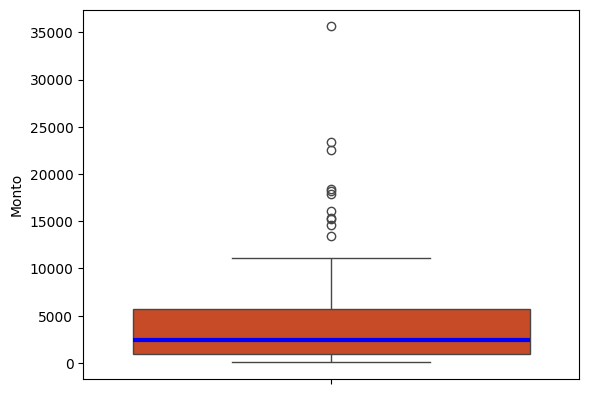

In [16]:
sbn.boxplot(clientes_ventas["Monto"], orient='v', color="#E23D0B", medianprops={'color':'blue', 'linewidth': 3})
plt.show()

En la gráfica anterior podemos notar que la mayoría de los datos correspondientes al monto comprado por clientes se quedan cerca a la mediana y también podemos ver algunos valores atípicos correspondientes a los mayores compradores.

                  NombreCliente     Monto
0                  Ernst Handel  35631.21
1                Mère Paillarde  23362.60
2            Save-a-lot Markets  22500.06
3    Rattlesnake Canyon Grocery  18421.42
4                    QUICK-Stop  18178.80
5                 Queen Cozinha  17880.60
6              Piccolo und mehr  16040.75
7  Hungry Owl All-Night Grocers  15391.02
8          Blondel père et fils  15253.75
9                 Simons bistro  14619.00
El monto acumulado de los mejores 10 clientes es de:  197279.21


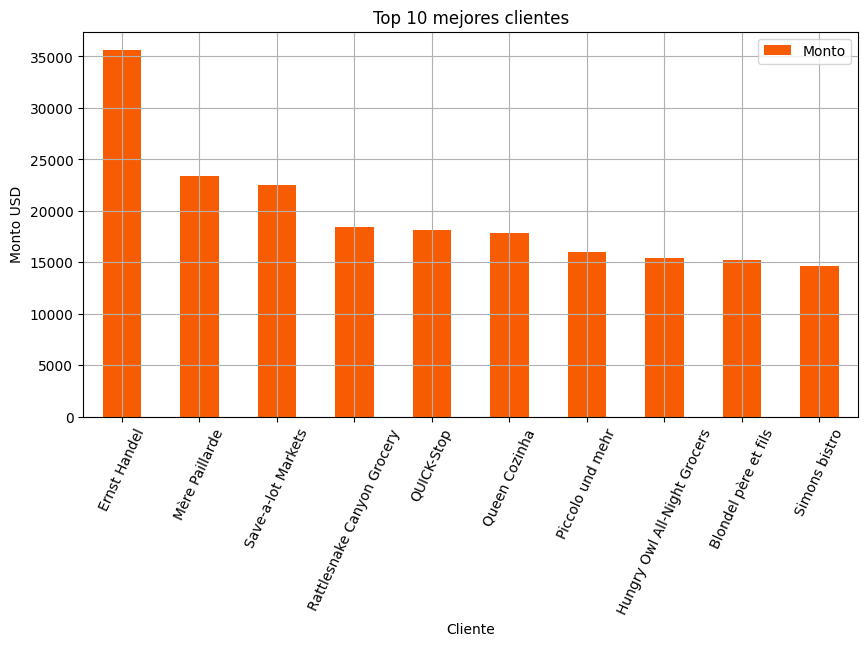

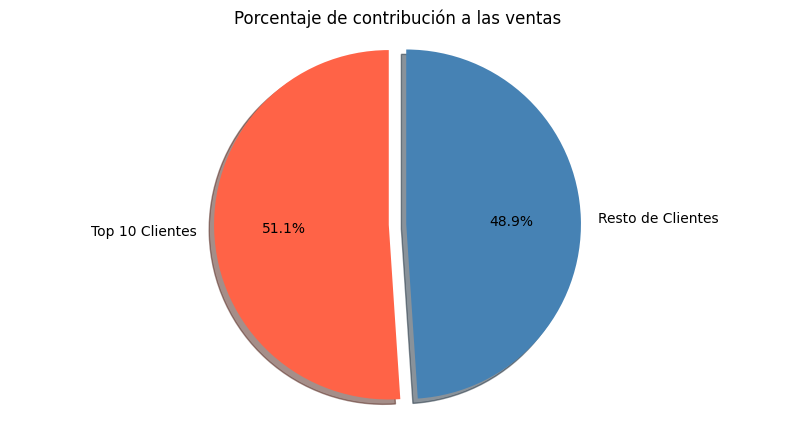

In [17]:
top10_clientes = clientes_ventas[["NombreCliente", "Monto"]].head(10)
print(top10_clientes)
Monto_top10 = top10_clientes["Monto"].sum()
print("El monto acumulado de los mejores 10 clientes es de: ", Monto_top10)
Monto_resto_clientes = monto_total - Monto_top10

#Gráfica de los 10 mejores clientes
top10_clientes.plot(x='NombreCliente', y='Monto', figsize=(10, 5), color="#F85C02", kind='bar')
plt.title("Top 10 mejores clientes")
plt.grid()
plt.xlabel("Cliente")
plt.ylabel("Monto USD")
plt.xticks(rotation=65)
plt.show()

#Gráfica porcentajes
plt.figure(figsize=(10, 5))
plt.pie([Monto_top10, Monto_resto_clientes], explode = (0.1, 0), 
        labels=["Top 10 Clientes", 
                "Resto de Clientes"],
        colors = ['#FF6347', '#4682B4'], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Porcentaje de contribución a las ventas")
plt.axis('equal') 
plt.show()


Podemos observar nuestros 10 mejores clintes de los cuales el cliente que más ha comprado es Ernst Handel con $35631.21 USD. También notemos que la suma del monto de los 10 mejores clientes es de $197279.21 USD que representa un 51.1% de las ventas totales.

                         NombreCliente   Monto
64                              Wolski  573.75
65                         Wilman Kala  566.00
66             Antonio Moreno Taquería  504.00
67                    LINO-Delicateses  500.00
68                      The Big Cheese  421.00
69              Océano Atlántico Ltda.  399.00
70                     Du monde entier  336.00
71          Centro comercial Moctezuma  126.00
72  Ana Trujillo Emparedados y helados  111.00
73                      Franchi S.p.A.   62.46
Monto comprado por los 10 peores clientes 3599.21


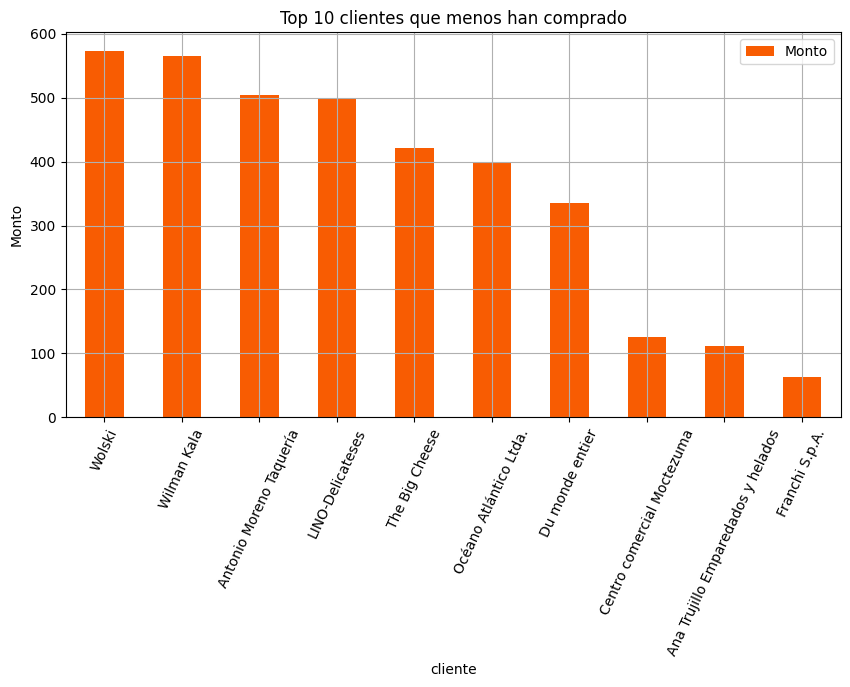

In [18]:
Peores10_clientes = clientes_ventas[["NombreCliente", "Monto"]].tail(10)
print(Peores10_clientes)
print("Monto comprado por los 10 peores clientes", Peores10_clientes["Monto"].sum())

Peores10_clientes.plot(x='NombreCliente', y='Monto', figsize=(10, 5), color='#F85C02', kind='bar')
plt.title("Top 10 clientes que menos han comprado")
plt.grid()
plt.xlabel("cliente")
plt.ylabel("Monto")
plt.xticks(rotation=65)
plt.show()

En la gráfica podemos ver los 10 clientes que menos han comprado y entre todos acumulan la suma de $3599.21 USD que representa un 0.93%

In [19]:
print(clientes_ventas["UnidadesVendidas"].describe())

count      74.000000
mean      172.202703
std       223.491410
min         2.000000
25%        45.750000
50%        97.500000
75%       189.750000
max      1418.000000
Name: UnidadesVendidas, dtype: float64


Ahora podemos notar que en promedio los clientes han comprado 172 articulos y la desviación estándar es de 223 lo cual es alta, lo que hace nos dice que hay clientes que compran mucho pero también hay clientes casuales. Hay un máximo de 1418 articlulos comprados y un mínimo de 2.

In [20]:
#Retención de Clientes
query2 = '''
        SELECT c.CustomerName as NombreCliente, count(o.OrderID) as NumeroDeOrdenes FROM Customers c
        JOIN Orders o ON c.CustomerID = o.CustomerID
        GROUP BY c.CustomerName
        ORDER BY NumeroDeOrdenes DESC

        '''
ordenes_clientes = pd.read_sql_query(query2, conn)
print(ordenes_clientes)

print(ordenes_clientes.info())
print(ordenes_clientes.duplicated(subset=['NombreCliente']).any())

                         NombreCliente  NumeroDeOrdenes
0                         Ernst Handel               10
1                       Wartian Herkku                7
2           Rattlesnake Canyon Grocery                7
3                           QUICK-Stop                7
4                Split Rail Beer & Ale                6
..                                 ...              ...
69          Centro comercial Moctezuma                1
70           Bólido Comidas preparadas                1
71                      B''s Beverages                1
72             Antonio Moreno Taquería                1
73  Ana Trujillo Emparedados y helados                1

[74 rows x 2 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   NombreCliente    74 non-null     object
 1   NumeroDeOrdenes  74 non-null     int64 
dtypes: int64(1), objec

Obtuvimos el número de ordenes por cliente y ahora nos es interesante saber cuáles clientes regresaron a comprar después de su primera compra.

                     NombreCliente  NumeroDeOrdenes
0                     Ernst Handel               10
1                   Wartian Herkku                7
2       Rattlesnake Canyon Grocery                7
3                       QUICK-Stop                7
4            Split Rail Beer & Ale                6
5     Hungry Owl All-Night Grocers                6
6                   Mère Paillarde                5
7                La maison d''Asie                5
8                LILA-Supermercado                5
9              Tortuga Restaurante                4
10              Save-a-lot Markets                4
11                     Que Delícia                4
12          Old World Delicatessen                4
13                  Frankenversand                4
14                  Folk och fä HB                4
15               Die Wandernde Kuh                4
16          Bottom-Dollar Marketse                4
17            Blondel père et fils                4
18          

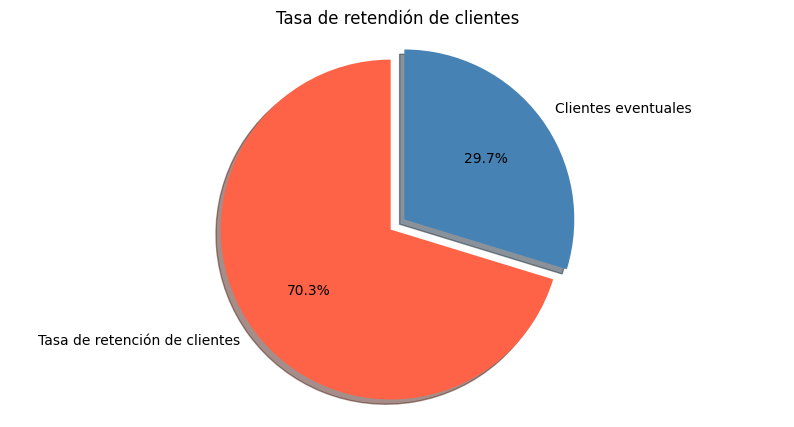

In [21]:
clientes_leales = ordenes_clientes[ordenes_clientes["NumeroDeOrdenes"] >= 2]
clientes_eventuales = ordenes_clientes[ordenes_clientes["NumeroDeOrdenes"] < 2]

print(clientes_leales)
print("Los clientes leales son: ", len(clientes_leales))
print("La tasa de retención es de: ", (len(clientes_leales)/74)*100, "%")

plt.figure(figsize=(10, 5)) 
plt.pie([len(clientes_leales), len(clientes_eventuales)], explode = (0.1, 0), 
        labels=["Tasa de retención de clientes", 
                "Clientes eventuales"],
        colors = ['#FF6347', '#4682B4'], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Tasa de retendión de clientes")
plt.axis('equal') 
plt.show()



Según los datos, tenemos que la Tasa de Retención de Clientes (Regresan después de su primera compra) es de cerca del 70.3% y el otro 29.7% no regresan después de comprar.

In [22]:
ordenes_totales = ordenes_clientes["NumeroDeOrdenes"].sum()
print("Las ordenes totales son: ", ordenes_totales)

valor_promedio_pedido = monto_total/ordenes_totales
print("El valor promedio por pedido es de: ", valor_promedio_pedido)

Las ordenes totales son:  196
El valor promedio por pedido es de:  1971.5521938775512


Destaquemos que el Valor Promedio por Pedido es de $1971.552 USD

In [23]:
#Países info

query3 = '''
        SELECT c.Country as País, sum(od.Quantity * p.Price) as Monto, count(DISTINCT c.CustomerID) as NúmeroDeClientes FROM Customers c
        JOIN Orders o ON c.CustomerID = o.CustomerID 
        jOIN OrderDetails od ON o.OrderID = od.OrderID
        jOIN Products p ON od.ProductID = p.ProductID
        GROUP BY c.Country
        ORDER BY Monto DESC
'''

pais_ventas = pd.read_sql_query(query3, conn)
print(pais_ventas)

           País     Monto  NúmeroDeClientes
0           USA  69611.75                 8
1       Austria  51671.96                 2
2       Germany  47241.82                 9
3        Brazil  40215.25                 9
4        Canada  31326.35                 2
5        France  29549.15                 7
6       Denmark  17870.85                 2
7            UK  16695.79                 6
8       Ireland  15391.02                 1
9     Venezuela  13556.28                 4
10       Sweden   9720.80                 2
11  Switzerland   8124.75                 2
12      Belgium   8051.30                 1
13      Finland   6438.50                 2
14       Mexico   5861.56                 5
15        Italy   4328.56                 3
16        Spain   4302.19                 4
17     Portugal   4170.00                 2
18       Norway   1323.60                 1
19       Poland    573.75                 1
20    Argentina    399.00                 1


Hacemos una consulta para saber cuanto dinero se recaudo en cada país y el número de clientes de cada uno.

In [24]:
print(pais_ventas.info())
print(pais_ventas.isna().sum())
print(pais_ventas.duplicated(subset=['País']).any())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   País              21 non-null     object 
 1   Monto             21 non-null     float64
 2   NúmeroDeClientes  21 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 636.0+ bytes
None
País                0
Monto               0
NúmeroDeClientes    0
dtype: int64
False


En esta tabla no hay registros duplicados ni valores faltantes por lo que no es necesario algún método de imputación.

In [25]:
print(pais_ventas.describe())

              Monto  NúmeroDeClientes
count     21.000000         21.000000
mean   18401.153810          3.523810
std    19346.152532          2.731649
min      399.000000          1.000000
25%     4328.560000          2.000000
50%     9720.800000          2.000000
75%    29549.150000          5.000000
max    69611.750000          9.000000


Hay presencia en 21 países y podemos destacar que en promedio cada país a comprado $18401.15 USD y tiene una media de 3.5 clientes. La desviación estándar es de $19346.15 USD El monto máximo es de $69611.75 USD de Estados Unidos y el mínimo es de $399 USD de Argentina. También tenemos que el país con más clientes son Brasil y Alemenia con 9 y los de menos clientes son Argentina, Polonia y Noruega con 1 cada uno. También notemos que la distancia intercuartil del monto es de $25220.59 USD.

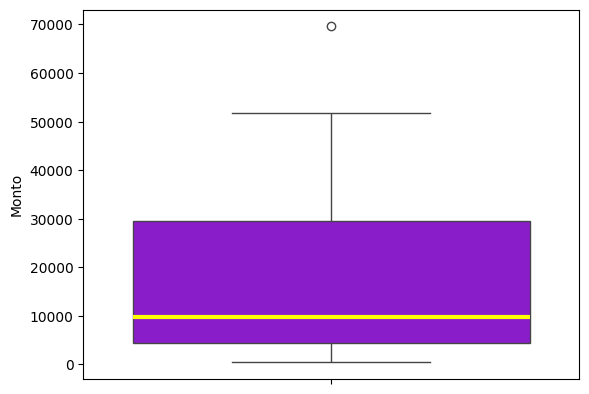

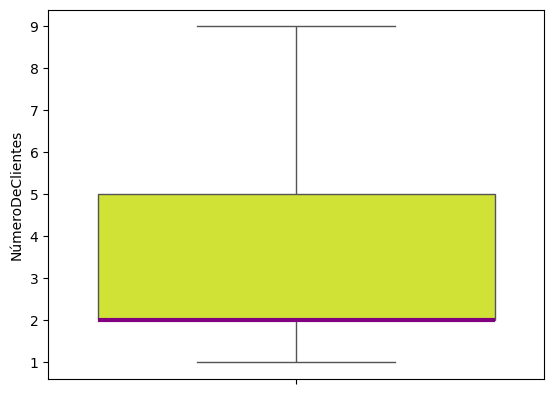

In [26]:
pais_monto = pais_ventas["Monto"]
pais_clientes = pais_ventas["NúmeroDeClientes"]

sbn.boxplot(pais_monto, orient='v', color="#9200E7", medianprops={'color':'yellow', 'linewidth': 3})
plt.show()

sbn.boxplot(pais_clientes, orient='v', color="#E8FF19", medianprops={'color':'purple', 'linewidth': 3})
plt.show()


Como podemos ver en la primer imágen, correspondiente al monto vendido, los datos están muy dispersos pues la distancia intercuartil es muy grande. También notemos que sólo hay un dato atípico que es el monto correspondiente a Estados Unidos. En la segunda imagen, correspondiente a los clientes por país, los datos están relativamente más dispersos, y por encima de la mediana, el 50% del número de clientes se concentra entre 2 y 5, y no hay datos atípicos.

        País     Monto  NúmeroDeClientes
0        USA  69611.75                 8
1    Austria  51671.96                 2
2    Germany  47241.82                 9
3     Brazil  40215.25                 9
4     Canada  31326.35                 2
5     France  29549.15                 7
6    Denmark  17870.85                 2
7         UK  16695.79                 6
8    Ireland  15391.02                 1
9  Venezuela  13556.28                 4
           País    Monto  NúmeroDeClientes
11  Switzerland  8124.75                 2
12      Belgium  8051.30                 1
13      Finland  6438.50                 2
14       Mexico  5861.56                 5
15        Italy  4328.56                 3
16        Spain  4302.19                 4
17     Portugal  4170.00                 2
18       Norway  1323.60                 1
19       Poland   573.75                 1
20    Argentina   399.00                 1


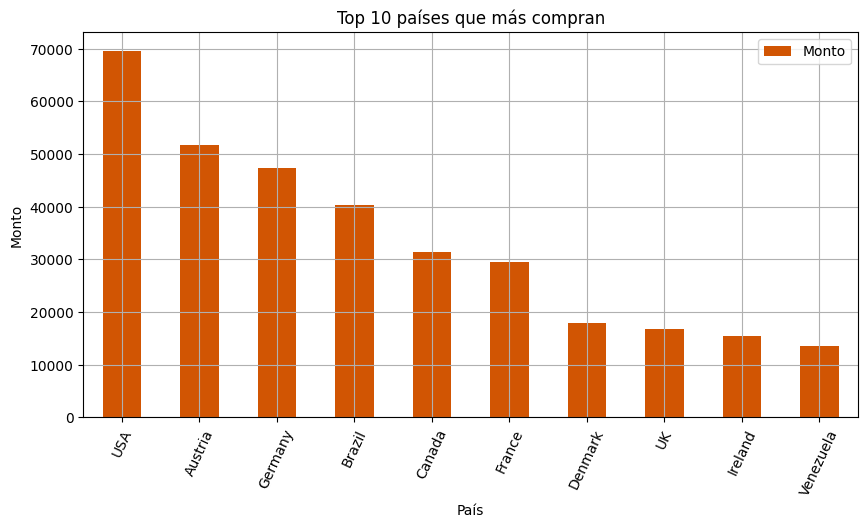

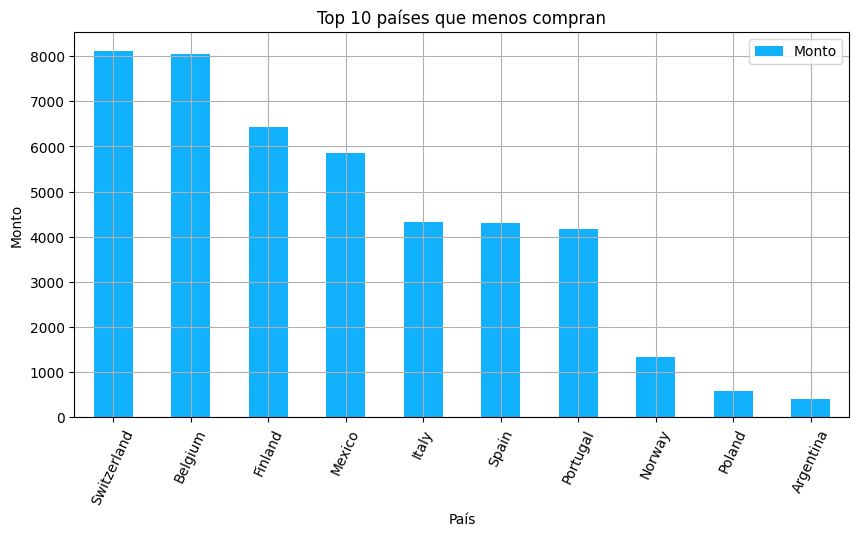

In [27]:
#Top 10 mejores países para vender
mejores_paises = pais_ventas.head(10)
peores_paises = pais_ventas.tail(10)

#Monto de los 10 mejores países y del resto
monto_10paises = mejores_paises["Monto"].sum()
resto_paises = monto_total-monto_10paises

print(mejores_paises)
print(peores_paises)

#Top 10 mejores países
mejores_paises[["País", "Monto"]].plot(x='País', y='Monto', figsize=(10, 5), kind='bar', color="#D15503")
plt.title("Top 10 países que más compran")
plt.grid()
plt.xlabel("País")
plt.ylabel("Monto")
plt.xticks(rotation=65)
plt.show()

#Top 10 peores países

peores_paises[["País", "Monto"]].plot(x='País', y='Monto', figsize=(10, 5), kind='bar', color="#11B1FC")
plt.title("Top 10 países que menos compran")
plt.grid()
plt.xlabel("País")
plt.ylabel("Monto")
plt.xticks(rotation=65)
plt.show()

El país que más compra históricamente es Estados Unidos con $69611.75 USD y el que menos compra es Argentina con $399 USD.

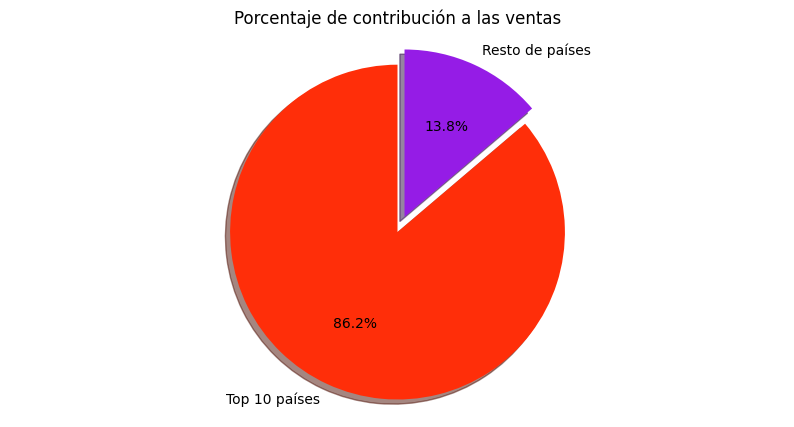

In [28]:
plt.figure(figsize=(10, 5))
plt.pie([monto_10paises,resto_paises], explode = (0.1, 0), 
        labels=["Top 10 países", 
                "Resto de países"],
        colors = ["#FF2E09", "#951CE6"], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Porcentaje de contribución a las ventas")
plt.axis('equal') 
plt.show()


Tenemos que de los 21 países en los que se tiene presencia, el 86.2% de las ventas históricas se concentran en los 10 países que más compran.

In [29]:
#Fecha de ventas

query4 = '''
        SELECT OrderDate FROM Orders
        ORDER BY OrderDate DESC
        '''

historial_ordenes = pd.read_sql_query(query4, conn)
print(historial_ordenes)

      OrderDate
0    1997-02-12
1    1997-02-11
2    1997-02-10
3    1997-02-10
4    1997-02-07
..          ...
191  1996-07-09
192  1996-07-08
193  1996-07-08
194  1996-07-05
195  1996-07-04

[196 rows x 1 columns]


Como podemos ver en la tabla, las ventas tienen no más de 7 meses de antigüedad por lo que los datos representan la operación del último año. 

         País  NúmeroDeClientes
2     Germany                 9
3      Brazil                 9
0         USA                 8
5      France                 7
7          UK                 6
14     Mexico                 5
9   Venezuela                 4
16      Spain                 4
15      Italy                 3
4      Canada                 2
           País  NúmeroDeClientes
11  Switzerland                 2
6       Denmark                 2
17     Portugal                 2
13      Finland                 2
10       Sweden                 2
8       Ireland                 1
12      Belgium                 1
18       Norway                 1
19       Poland                 1
20    Argentina                 1


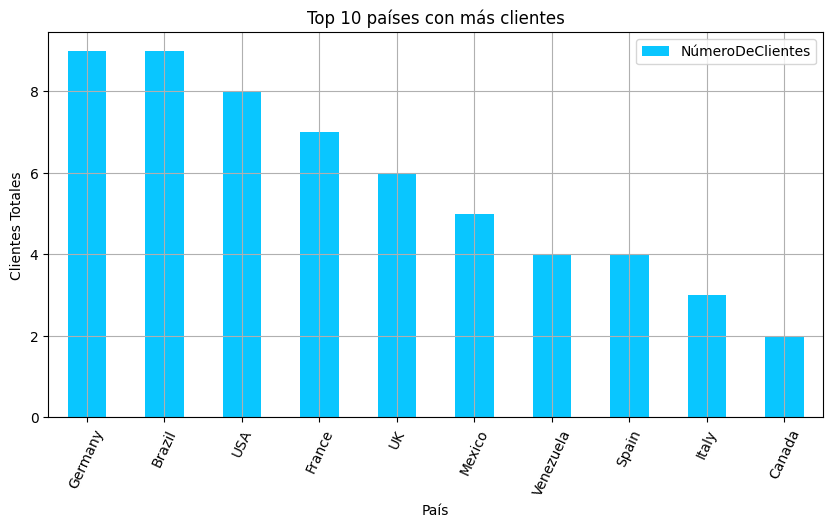

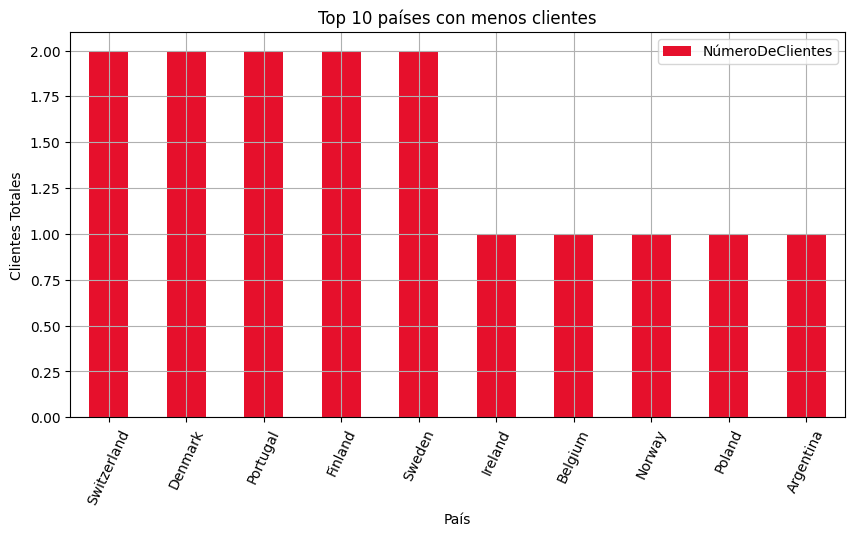

In [30]:
paises_clientes_ord = pais_ventas.sort_values(by="NúmeroDeClientes", ascending= False)

paises_mas_clientes = paises_clientes_ord[["País", "NúmeroDeClientes"]].head(10)
paises_menos_clientes = paises_clientes_ord[["País", "NúmeroDeClientes"]].tail(10)

print(paises_mas_clientes)
print(paises_menos_clientes)

paises_mas_clientes.plot(x='País', y='NúmeroDeClientes', figsize=(10, 5), kind='bar', color="#09C6FF")
plt.title("Top 10 países con más clientes")
plt.xlabel("País")
plt.ylabel("Clientes Totales")
plt.grid()
plt.xticks(rotation=65)
plt.show()

paises_menos_clientes.plot(x='País', y='NúmeroDeClientes', figsize=(10, 5), kind='bar', color="#E6102C")
plt.title("Top 10 países con menos clientes")
plt.xlabel("País")
plt.ylabel("Clientes Totales")
plt.grid()
plt.xticks(rotation=65)
plt.show()

Podemos destacar que en cuanto a número de clientes Alemania y Brasil se mantiene en primer lugar con 76 y Noruega, Polonia y Argentina en último con 1. También podemos notar que el monto por país y el número de clientes parecen estár correlacionados.

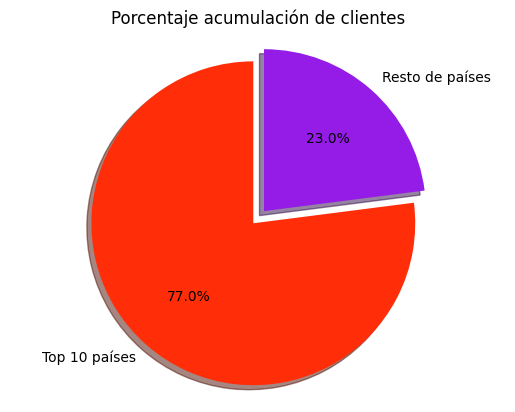

In [31]:
clientes_totales = pais_ventas['NúmeroDeClientes'].sum()
suma_10_paises = paises_mas_clientes['NúmeroDeClientes'].sum()
otros_clientes = clientes_totales - suma_10_paises

plt.pie([suma_10_paises, otros_clientes], explode = (0.1, 0), 
        labels=["Top 10 países", 
                "Resto de países"],
        colors = ["#FF2E09", "#951CE6"], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Porcentaje acumulación de clientes")
plt.axis('equal') 
plt.show()


Notemos que el 77% de los clientes se concentran en los 10 países con más clientes.

Correlación monto/clientes:  0.650419968112742


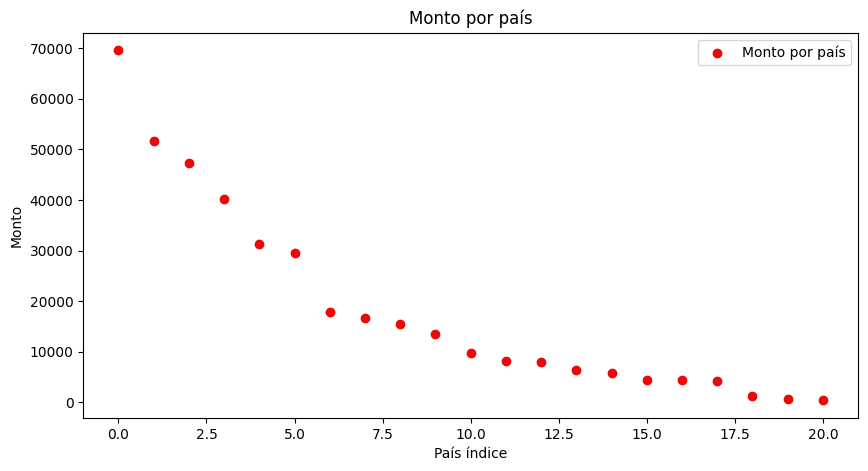

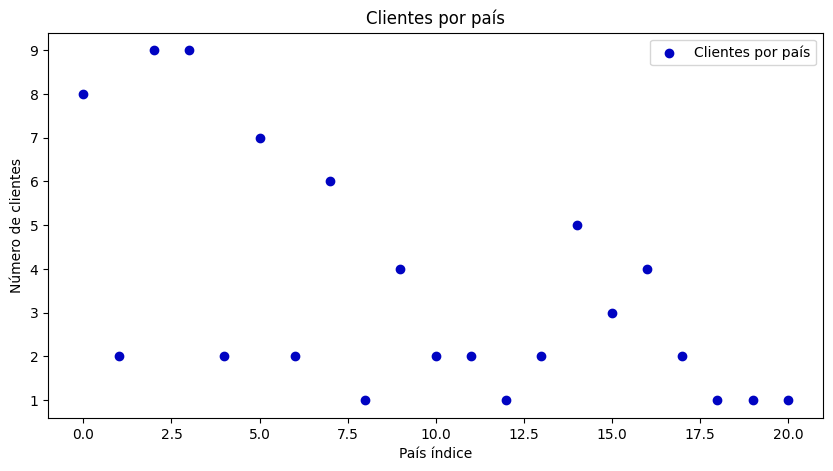

In [32]:
#Correlación
corr_monto_cliente = pais_monto.corr(pais_clientes)
print("Correlación monto/clientes: ", corr_monto_cliente)

plt.figure(figsize=(10, 5))
plt.scatter(x=pais_monto.index, y=pais_monto, color="#EE0707", label='Monto por país')
plt.title("Monto por país")
plt.xlabel("País índice")
plt.ylabel("Monto")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(x=pais_clientes.index, y=pais_clientes, color="#0003C2", label='Clientes por país')
plt.title("Clientes por país")
plt.xlabel("País índice")
plt.ylabel("Número de clientes")
plt.legend()
plt.show()


La correlación no es muy alta (0.65) pero es positiva por lo que podemos concluír que hay cierta relación proporcional entre la cantidad de clientes y el monto por país pero hay casos donde unos pocos clientes compran mucho y hay países donde varios clientes han comprado muy poco.

In [33]:
#Productos ventas
query5 = ''' 
        SELECT p.ProductName as Producto, sum(od.Quantity) as UnidadesVendidas, p.Price as Precio, sum(p.Price * od.Quantity) as Monto FROM Products p
        JOIN OrderDetails od ON p.ProductID = od.ProductID
        GROUP BY p.ProductName
        ORDER BY Monto DESC
        '''
ventas_productos = pd.read_sql_query(query5, conn)
print(ventas_productos)

                     Producto  UnidadesVendidas  Precio     Monto
0               Côte de Blaye               239  263.50  62976.50
1     Thüringer Rostbratwurst               168  123.79  20796.72
2        Raclette Courdavault               346   55.00  19030.00
3              Tarte au sucre               325   49.30  16022.50
4           Camembert Pierrot               430   34.00  14620.00
..                        ...               ...     ...       ...
72               Genen Shouyu                25   15.50    387.50
73        Gustaf's Knäckebröd                18   21.00    378.00
74                   Filo Mix                48    7.00    336.00
75                Røgede sild                15    9.50    142.50
76  Laughing Lumberjack Lager                 5   14.00     70.00

[77 rows x 4 columns]


Extraémos la tabla con el nómbre del producto, las unidades vendidas y el monto vendido.

In [34]:
print(ventas_productos.info())
print(ventas_productos.isna().sum())
print(ventas_productos.duplicated(subset='Producto').any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Producto          77 non-null     object 
 1   UnidadesVendidas  77 non-null     int64  
 2   Precio            77 non-null     float64
 3   Monto             77 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.5+ KB
None
Producto            0
UnidadesVendidas    0
Precio              0
Monto               0
dtype: int64
False


No hay valores faltantes ni registros duplicados por lo que no es necesario algún método de imputación.

In [35]:
print(ventas_productos.describe())

unidades_totales = ventas_productos["UnidadesVendidas"].sum()
#El monto total ya lo calculamos

print("Unidades totales vendidas: ", unidades_totales)
print("Monto total de los productos vendidos: ", monto_total)

       UnidadesVendidas      Precio         Monto
count         77.000000   77.000000     77.000000
mean         165.493506   28.866364   5018.496494
std          102.394570   33.815111   7938.002912
min            5.000000    2.500000     70.000000
25%           90.000000   13.250000   1137.500000
50%          159.000000   19.500000   2862.000000
75%          209.000000   33.250000   6256.000000
max          458.000000  263.500000  62976.500000
Unidades totales vendidas:  12743
Monto total de los productos vendidos:  386424.23000000004


Notemos que en se han vendido 77 productos diferentes, los cuales en total han vendido 12743 unidades y un monto en conjunto de $386424.23 USD. En promedio cada producto ha vendido 165.49 unidades y obtenido un monto de $5018.49 USD. También se tiene que la desviación estándar es de 102.39 productos vendidos y de $5018.49 USD. La distancia intercuartil de las unidades vendidas es de 119 unidades y de el monto es de $5118.5 USD. También notemos que la media en el precio de los productos es de $28.86 USD y la desviación estándar es de $33.81 USD.

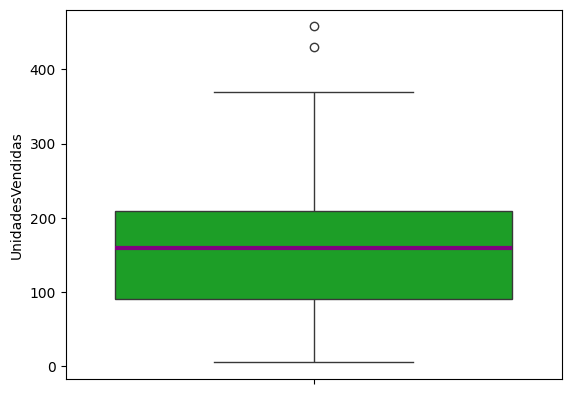

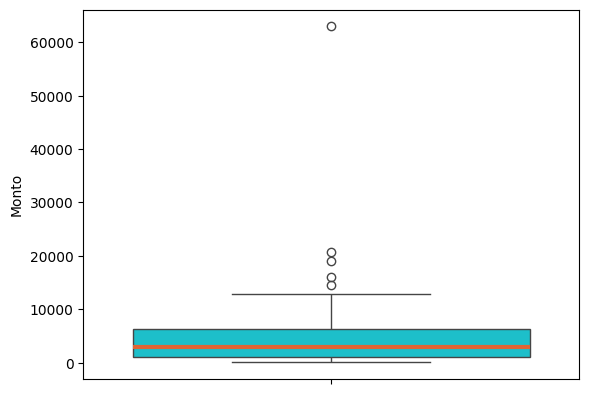

In [36]:
producto_unidades_vendidas = ventas_productos[["Producto", "UnidadesVendidas"]]
producto_monto = ventas_productos[["Producto", "Monto"]]

sbn.boxplot(producto_unidades_vendidas["UnidadesVendidas"], orient='v', color="#07B415", medianprops={'color':'purple', 'linewidth': 3})
plt.show()

sbn.boxplot(producto_monto["Monto"], orient='v', color="#00D8E7", medianprops={'color':"#E06535", 'linewidth': 3})
plt.show()



Podemos notar en la primer gráfica, correspondiente a las unidades vendidas por artículo, que los datos se mantienen no tan excesivamente lejos de la mediana y hay un par de datos atípicos de productos que se vendieron mucho. En la segunda gráfica vemos que los datos están relativamente compactos y hay algunos datos atípicos de productos que recaudaron un gran monto de dinero.

                  Producto     Monto
0            Côte de Blaye  62976.50
1  Thüringer Rostbratwurst  20796.72
2     Raclette Courdavault  19030.00
3           Tarte au sucre  16022.50
4        Camembert Pierrot  14620.00
5             Alice Mutton  12909.00
6   Gnocchi di nonna Alice  10222.00
7   Mozzarella di Giovanni   9396.00
8             Vegie-spread   9175.10
9    Manjimup Dried Apples   8639.00
                Producto  UnidadesVendidas
21     Gorgonzola Telino               458
4      Camembert Pierrot               430
15        Steeleye Stout               369
2   Raclette Courdavault               346
18                 Chang               341
20               Pavlova               338
14           Fløtemysost               336
5           Alice Mutton               331
3         Tarte au sucre               325
67               Geitost               316


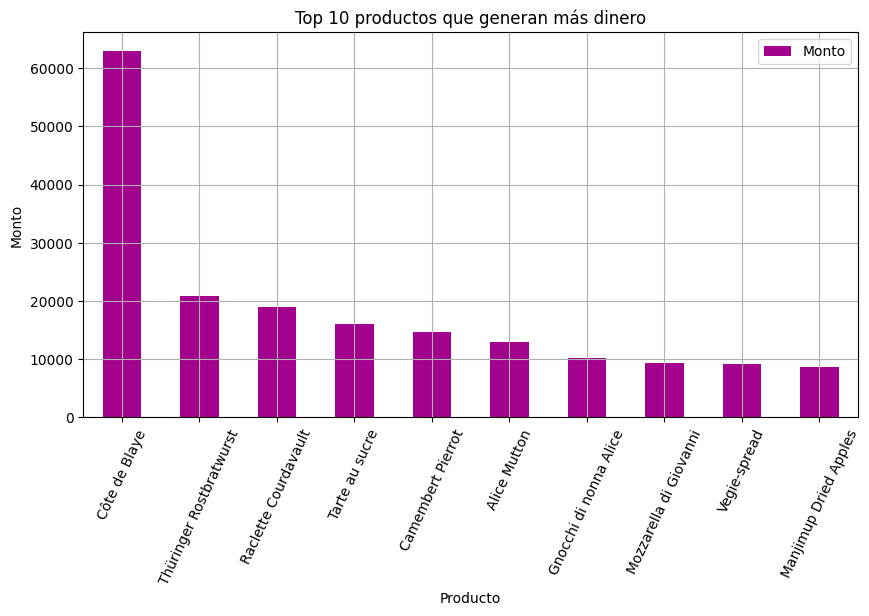

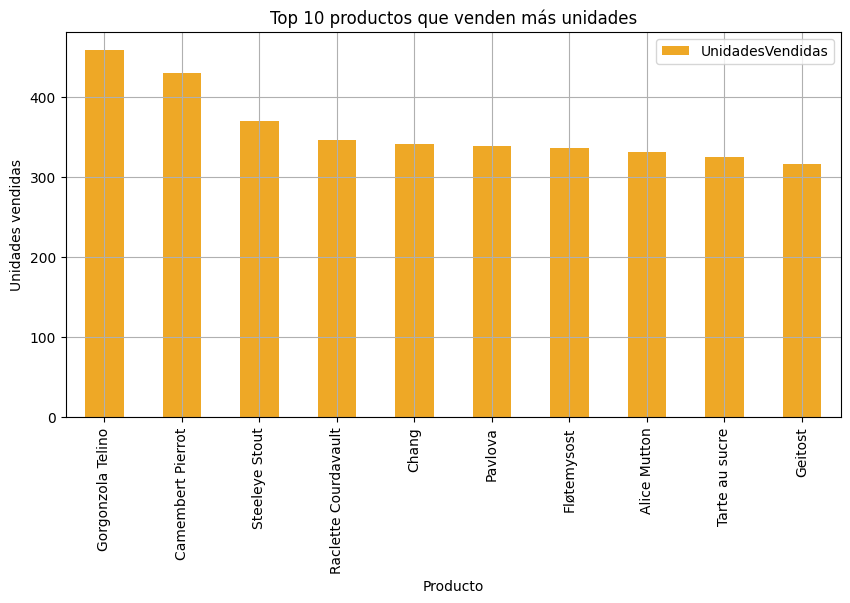

In [37]:
top10_productos_monto = producto_monto.head(10)
top10_productos_unidades = producto_unidades_vendidas.sort_values(by="UnidadesVendidas", ascending=False).head(10)

print(top10_productos_monto)
print(top10_productos_unidades)

top10_productos_monto.plot(x='Producto', y='Monto', kind='bar', color="#A3028E", figsize=(10, 5))
plt.title("Top 10 productos que generan más dinero")
plt.xlabel("Producto")
plt.ylabel("Monto")
plt.grid()
plt.xticks(rotation=65)
plt.show()

top10_productos_unidades.plot(x='Producto', y='UnidadesVendidas', kind='bar', color="#EEA826", figsize=(10, 5))
plt.title("Top 10 productos que venden más unidades")
plt.xlabel("Producto")
plt.ylabel("Unidades vendidas")
plt.grid()
plt.show()

Podemos ver que el producto que más dinero recaudó es Côte de Blaye con $62976.50 USD aunque esto es el dinero que vende pero sin tomar en cuanta el precio de inversión, por lo que no podemos saber de cuánto es la ganancia neta, y la alta suma se debe a que es el producto más caro. Ahora notemos que el producto que más se vende es Gorgonzola Telino con 458 unidades aunque este no figura en los 10 productos que generan más dinero.

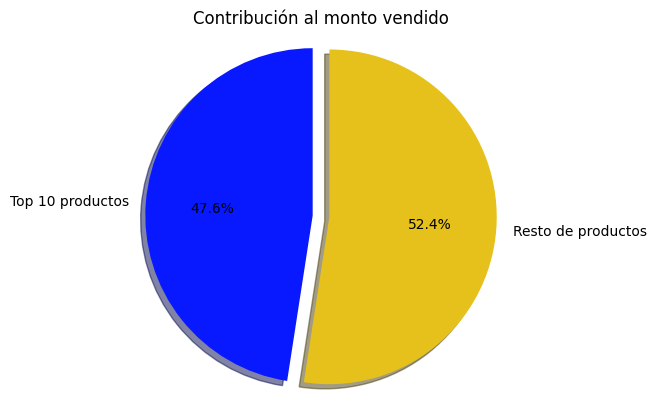

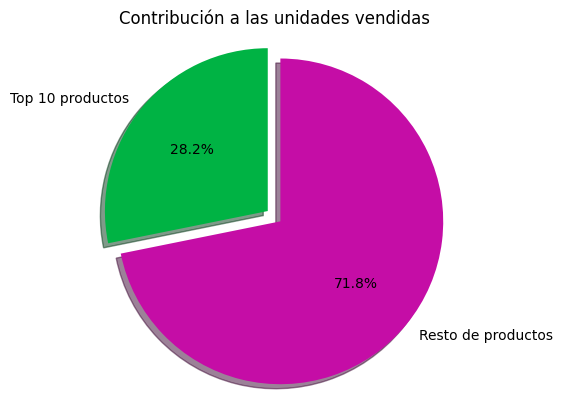

In [38]:
top10_producto_total = top10_productos_monto["Monto"].sum()
top10_unidades_totales = top10_productos_unidades["UnidadesVendidas"].sum()

resto_productos = monto_total - top10_producto_total
resto_productos_unidades = unidades_totales - top10_unidades_totales

plt.pie([top10_producto_total, resto_productos], explode = (0.1, 0), 
        labels=["Top 10 productos", 
                "Resto de productos"],
        colors = ["#0919FF", "#E6C11C"], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Contribución al monto vendido")
plt.axis('equal') 
plt.show()

plt.pie([top10_unidades_totales, resto_productos_unidades], explode = (0.1, 0), 
        labels=["Top 10 productos", 
                "Resto de productos"],
        colors = ["#00B344", "#C50DA6"], autopct='%1.1f%%', shadow=True, startangle=90 )
plt.title("Contribución a las unidades vendidas")
plt.axis('equal') 
plt.show()


Los 10 productos con más dinero recaudado acumulan el 47.6% de las ventas totales, mientras que acumulan el 28.2% de las unidades totales vendidas. Entonces veamos que aunque generen muchos ingresos brutos las ganancias pueden ocupar un menor porcentaje dependiendo del margen de ganancia de cada producto.

In [39]:
print("Productos más baratos \n", ventas_productos[["Producto", "Precio"]].sort_values(by="Precio", ascending=False).tail(20))

Productos más baratos 
                            Producto  Precio
45           Escargots de Bourgogne   13.25
55  Original Frankfurter grüne Soße   13.00
65                        Chocolade   12.75
21                Gorgonzola Telino   12.50
41              Scottish Longbreads   12.50
48                        Spegesild   12.00
47                    Longlife Tofu   10.00
66                    Aniseed Syrup   10.00
54              Sir Rodney's Scones   10.00
56  Jack's New England Clam Chowder    9.65
63                    Zaanse koeken    9.50
75                      Røgede sild    9.50
49       Teatime Chocolate Biscuits    9.20
53                         Tunnbröd    9.00
58             Rhönbräu Klosterbier    7.75
44                        Tourtière    7.45
74                         Filo Mix    7.00
71                            Konbu    6.00
69               Guaraná Fantástica    4.50
67                          Geitost    2.50


Veamos que el producto más vendido (Gorgonzola Telino) ocupa el lugar número 17 de los más baratos con un precio de $12.5 USD.

                           Producto  Monto
67                          Geitost  790.0
68  Uncle Bob's Organic Dried Pears  750.0
69               Guaraná Fantástica  711.0
70                       Röd Kaviar  675.0
71                            Konbu  552.0
72                     Genen Shouyu  387.5
73              Gustaf's Knäckebröd  378.0
74                         Filo Mix  336.0
75                      Røgede sild  142.5
76        Laughing Lumberjack Lager   70.0
                           Producto  UnidadesVendidas
70                       Röd Kaviar                45
61                       Gravad lax                39
64     Grandma's Boysenberry Spread                36
60        Queso Manchego La Pastora                27
72                     Genen Shouyu                25
68  Uncle Bob's Organic Dried Pears                25
46                  Mishi Kobe Niku                20
73              Gustaf's Knäckebröd                18
75                      Røgede sild      

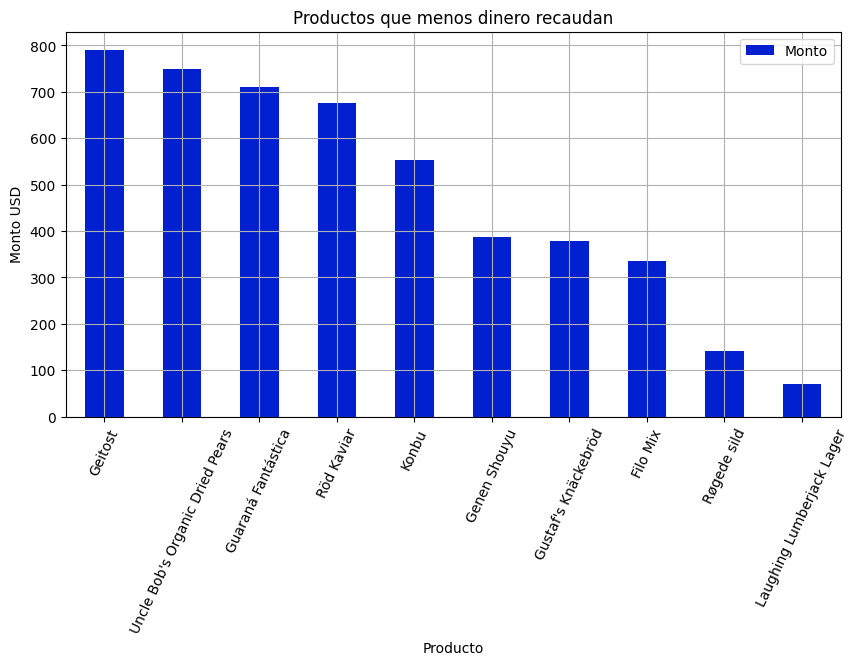

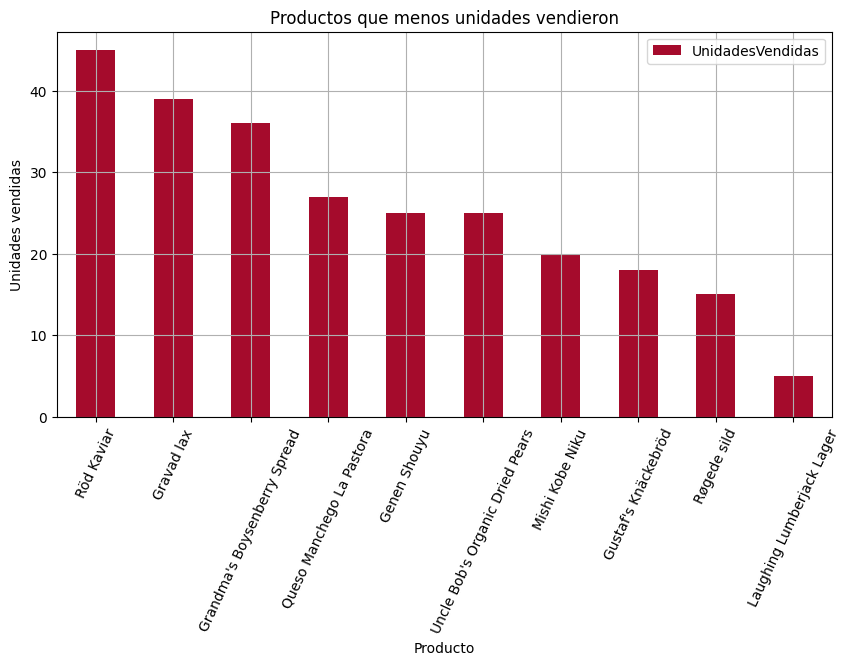

In [40]:
productos_menos_monto = producto_monto.tail(10)
productos_menos_unidades = producto_unidades_vendidas.sort_values(by="UnidadesVendidas", ascending=False).tail(10)

print(productos_menos_monto)
print(productos_menos_unidades)

productos_menos_monto.plot(x='Producto', y='Monto', kind='bar', color="#001FCF", figsize=(10, 5))
plt.title("Productos que menos dinero recaudan")
plt.xlabel("Producto")
plt.ylabel("Monto USD")
plt.grid()
plt.xticks(rotation=65)
plt.show()

productos_menos_unidades.plot(x='Producto', y='UnidadesVendidas', kind='bar', color="#A50B2C", figsize=(10, 5))
plt.title("Productos que menos unidades vendieron")
plt.xlabel("Producto")
plt.ylabel("Unidades vendidas")
plt.grid()
plt.xticks(rotation=65)
plt.show()


El producto que menos dinero genero es Laughing Lumberjack Lager con $70.0 USD aunque notemos que es de los productos más baratos y en general los productos que recaudaron menos dinero son de los más baratos. El producto que menos unidades vendió también es Laughing Lumberjack Lager con 5 unidades por lo que es un producto que no conviene mucho tenerlo en stock.

In [41]:
print(ventas_productos[["Producto", "Precio", "UnidadesVendidas"]].sort_values(by='Precio', ascending=False).head(10))

                   Producto  Precio  UnidadesVendidas
0             Côte de Blaye  263.50               239
1   Thüringer Rostbratwurst  123.79               168
46          Mishi Kobe Niku   97.00                20
11   Sir Rodney's Marmalade   81.00               106
16         Carnarvon Tigers   62.50               106
2      Raclette Courdavault   55.00               346
9     Manjimup Dried Apples   53.00               163
3            Tarte au sucre   49.30               325
19              Ipoh Coffee   46.00               136
10        Rössle Sauerkraut   45.60               189


Notemos que los productos más caros, exceptuando a Mishi Kobe Niku, venden bastante bien. Entonces no por ser caros venden pocas unidades.

La correlación Precio/Unidades Vendidas es:  0.1315675305650779


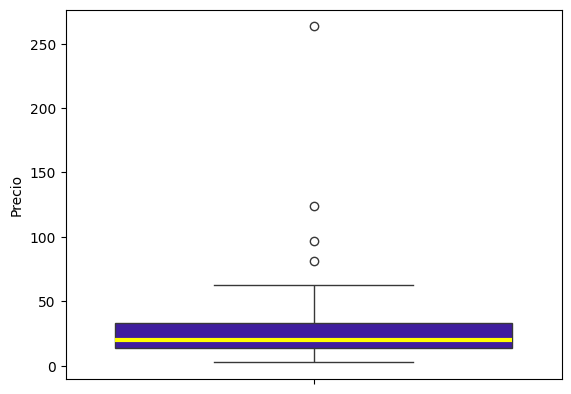

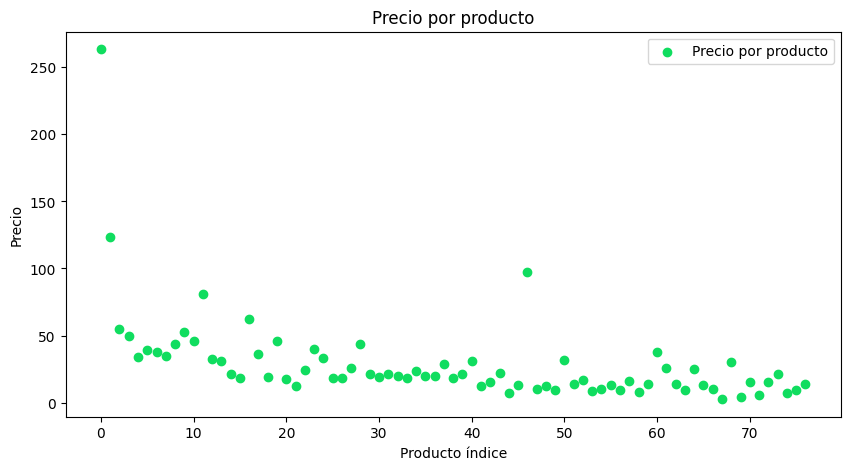

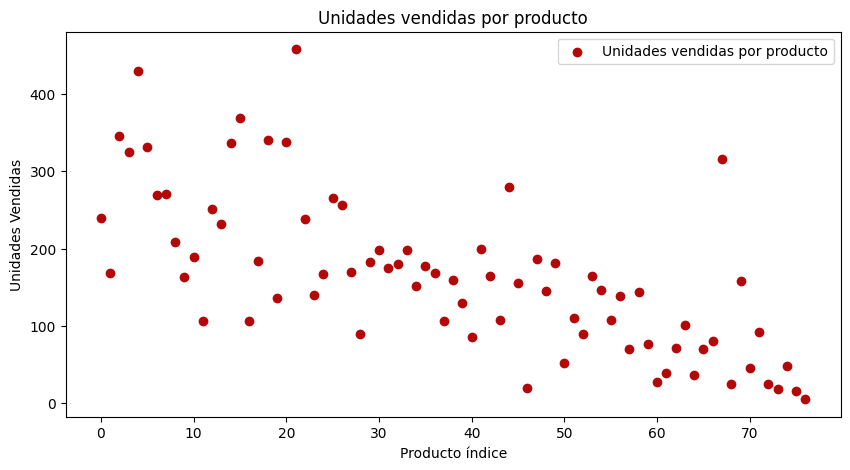

In [42]:
corr_unidades_precio = ventas_productos["Precio"].corr(ventas_productos["UnidadesVendidas"], method='spearman')
print("La correlación Precio/Unidades Vendidas es: ", corr_unidades_precio)

sbn.boxplot(ventas_productos["Precio"], orient='v', color="#3507B4", medianprops={'color':'yellow', 'linewidth': 3})
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(x=ventas_productos["Precio"].index, y=ventas_productos["Precio"], color="#10DD5F", label='Precio por producto')
plt.title("Precio por producto")
plt.xlabel("Producto índice")
plt.ylabel("Precio")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(x=ventas_productos["UnidadesVendidas"].index, y=ventas_productos["UnidadesVendidas"], color="#B40808", label='Unidades vendidas por producto')
plt.title("Unidades vendidas por producto")
plt.xlabel("Producto índice")
plt.ylabel("Unidades Vendidas")
plt.legend()

plt.show()

La correlación es muy cercana a 0 (0.131) por lo que efectivamente no hay relación entre el precio de los productos y las unidades que venden. Usé la correlación de Spearman por los outliers tan pronunciados en los precios. 

In [43]:
#Producto favorito por país
query6 = ''' WITH ventas_por_pais as (
    SELECT c."Country" as Pais, p."ProductName" as Producto, SUM(od."Quantity") as Unidades, ROW_NUMBER() OVER (
            PARTITION BY c."Country"
            ORDER BY SUM(od."Quantity") DESC) as rn FROM "Customers" c
    JOIN "Orders" o ON c."CustomerID" = o."CustomerID"
    JOIN "OrderDetails" od ON o."OrderID" = od."OrderID"
    JOIN "Products" p ON od."ProductID" = p."ProductID"
    GROUP BY c."Country", p."ProductName")
SELECT Pais, Producto, Unidades FROM ventas_por_pais
WHERE rn = 1
ORDER BY Pais;

'''

pais_preferencia = pd.read_sql_query(query6, conn)
print(pais_preferencia)

           Pais                          Producto  Unidades
0     Argentina                              Tofu        12
1       Austria            Chef Anton's Gumbo Mix        97
2       Belgium            Sir Rodney's Marmalade        40
3        Brazil                  Chartreuse verte        92
4        Canada                      Alice Mutton       120
5       Denmark               Scottish Longbreads        96
6       Finland                       Fløtemysost        70
7        France                    Tarte au sucre        75
8       Germany                  Boston Crab Meat       160
9       Ireland            Escargots de Bourgogne        80
10        Italy     Singaporean Hokkien Fried Mee        40
11       Mexico                          Maxilaku        30
12       Norway                Guaraná Fantástica        15
13       Poland                 Gorgonzola Telino        30
14     Portugal  Louisiana Fiery Hot Pepper Sauce        40
15        Spain              Rhönbräu Kl

También podemos ver el producto que más se vende por país.

In [44]:
#Empleados ventas
query7 = ''' 
        SELECT e.FirstName || ' ' || e.LastName as Empleado, count(o.OrderID) as Órdenes, sum(od.Quantity * p.Price) as Monto,
        sum(od.quantity) as UnidadesVendidas FROM Employees e
        JOIN Orders o ON e.EmployeeID = o.EmployeeID
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products p ON od.ProductID = p.ProductID
        GROUP BY Empleado
        ORDER BY Órdenes DESC
'''

empleados = pd.read_sql_query(query7, conn)
print(empleados)

           Empleado  Órdenes      Monto  UnidadesVendidas
0  Margaret Peacock      123  105696.50              3232
1     Nancy Davolio       78   57690.39              1924
2   Janet Leverling       74   42838.35              1725
3    Laura Callahan       68   39309.38              1293
4     Andrew Fuller       49   32503.16              1315
5    Michael Suyama       46   25399.25              1094
6       Robert King       34   39772.30               733
7   Steven Buchanan       27   27480.80               778
8    Anne Dodsworth       19   15734.10               649


Hacemos una consulta a la base de datos para extraer información de los empleados y podemos ver que Margaret Peacock es la empleada que más órdenes ha vendido con 123, más dinero a recaudado con $105696.50 USD y más unidades ha vendido con 3232 por lo que es la mejor vendedora. Por otro lado Anne Dodsworth es la vendedora que menos órdenes ha completado, menos dinero ha recaudado y menos unidades ha vendido. La diferencia entre la mejor empleada y la peór es de 104 ordenes y $89962.4 USD.

In [45]:
print(empleados.describe())

          Órdenes          Monto  UnidadesVendidas
count    9.000000       9.000000          9.000000
mean    57.555556   42936.025556       1415.888889
std     32.136860   26398.228189        809.493429
min     19.000000   15734.100000        649.000000
25%     34.000000   27480.800000        778.000000
50%     49.000000   39309.380000       1293.000000
75%     74.000000   42838.350000       1725.000000
max    123.000000  105696.500000       3232.000000


En promedio cada empleado ha completado 57.5 órdenes, vendido 1415.88 unidades e ingresado $42936.02 USD.

In [3]:
#Ventas por día
query8 = ''' 
        SELECT o.OrderDate as Fecha, sum(od.Quantity * p.Price) as Monto FROM Orders o
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products p ON od.ProductID = p.ProductID
        GROUP BY Fecha
        ORDER BY Fecha ASC

'''

ventas_dia = pd.read_sql_query(query8, conn)
print(ventas_dia)

conn.close()

          Fecha    Monto
0    1996-07-04   566.00
1    1996-07-05  2329.25
2    1996-07-08  3106.75
3    1996-07-09  4662.50
4    1996-07-10  1806.00
..          ...      ...
155  1997-02-06   710.50
156  1997-02-07  1348.70
157  1997-02-10  9441.01
158  1997-02-11  2246.00
159  1997-02-12   673.20

[160 rows x 2 columns]


Hacemos una consulta para ver las ventas por día.

In [4]:
ventas_dia_serie = ventas_dia.copy()
ventas_dia_serie["Fecha"] = pd.to_datetime(ventas_dia_serie["Fecha"])
ventas_dia_serie = ventas_dia_serie.set_index("Fecha")
print(ventas_dia_serie.info())
print(ventas_dia_serie.index.duplicated().any())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 160 entries, 1996-07-04 to 1997-02-12
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Monto   160 non-null    float64
dtypes: float64(1)
memory usage: 2.5 KB
None
False


Transformamos el dataframe en una serie, no hay valores nulos ni duplicados. 

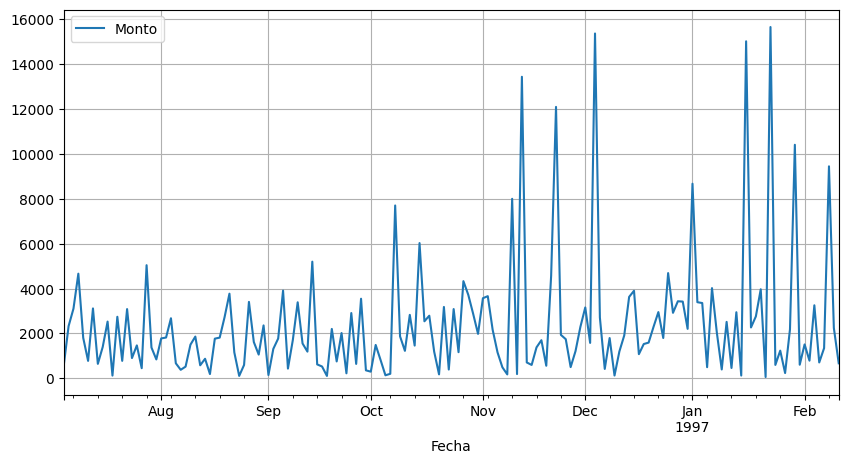

In [5]:
ventas_dia_serie.plot(figsize=(10, 5))
plt.grid()
plt.show()

En la gráfica de las ventas podemos ver que aparentemente no es estacional y tampoco parece haber una tendencia clara.

              Monto
count    160.000000
mean    2415.151437
std     2788.348288
min       62.460000
25%      673.500000
50%     1758.250000
75%     2986.500000
max    15641.500000


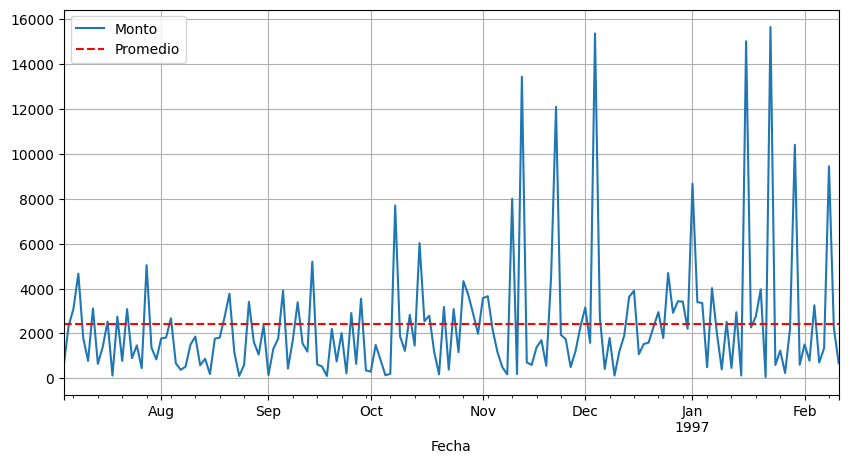

In [6]:
print(ventas_dia_serie.describe())

ventas_dia_serie.plot(figsize=(10, 5))
plt.hlines(ventas_dia_serie.mean(), xmin=ventas_dia_serie.index.min(), xmax=ventas_dia_serie.index.max(),colors='red', linestyles='--', label='Promedio')
plt.grid()
plt.legend()
plt.show()

En promedio cada día se vende un monto de $2415.15 USD, hay una desviación estandar de $2788.34 USD y la distancia intercuartíl es de $2313 USD.

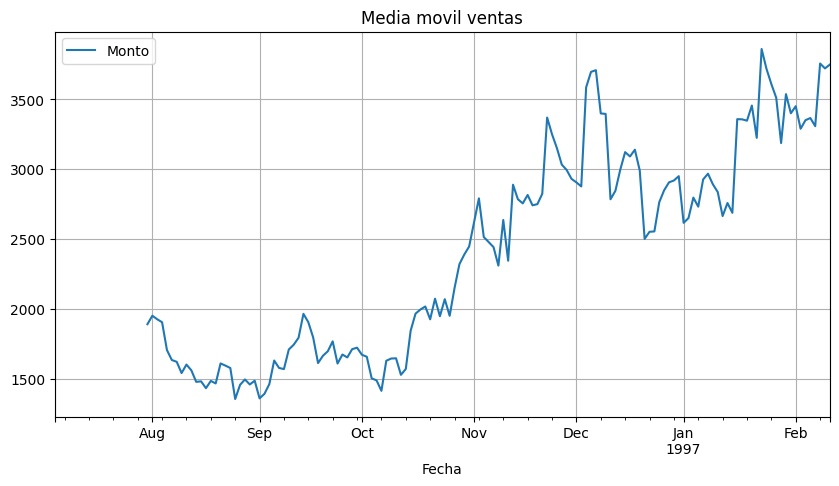

In [7]:
venas_media_movil = ventas_dia_serie.rolling(window=20).mean() #Como son semanas de 5 días

venas_media_movil.plot(figsize=(10, 5))
plt.title("Media movil ventas")
plt.grid()
plt.show()

Veamos que la media movil mensual aumenta con el tiempo pero puede ser por los valores que parecen atípicos, pues esta es sensible a estos datos.

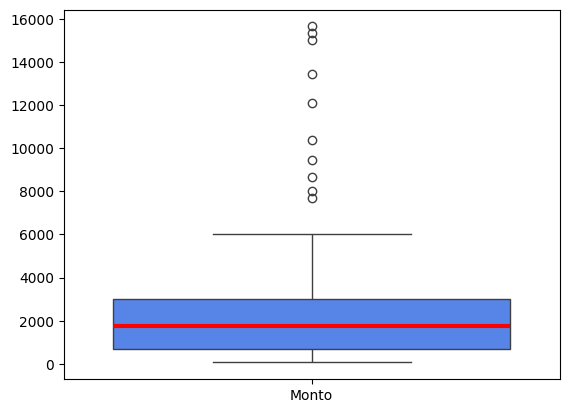

In [51]:
sbn.boxplot(ventas_dia_serie, orient='v', color="#3F7CFF", medianprops={'color':'red', 'linewidth': 3})
plt.show()

La mayoría de los datos se mantienen cerca de la mediana pero hay varios datos atípicos de días con muchas ventas

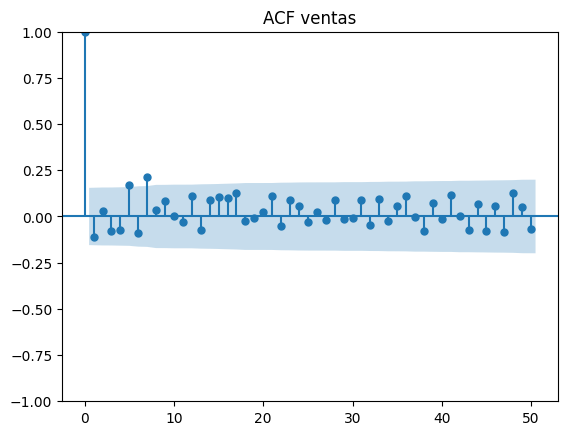

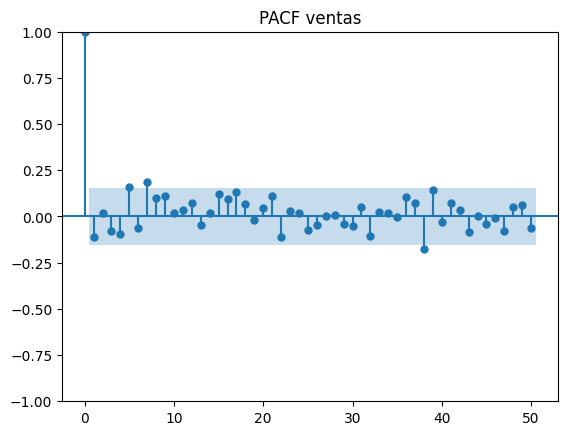

In [52]:
plot_acf(ventas_dia_serie, lags=50)
plt.title("ACF ventas")
plt.show()

plot_pacf(ventas_dia_serie, lags=50)
plt.title("PACF ventas")
plt.show()



Como podemos ver en la gráfica de la autocorrelación en los primeros 50 lags esta cae rapidamente a cero por lo que no hay tendencia y tampoco se ven patrones periodicos que indiquen estacionalidad, por lo que la diferenciación es 0. Ahora podemos ver en la gráfica de la autocorrelación parcial que cae rapidamente por lo que no parece haber una correlación a largo plazo y el componente autorregresivo a lo maximo es 1, por lo que la hipotesis es que un modelo que represente bien nuestra serie sería de suavización exponencial simple o ARIMA de bajo orden.

In [53]:
result = adfuller(ventas_dia_serie)

print("Test de Dickey-Fuller Aumentado (ADF)")
print(f"Estadístico ADF: {result[0]:.4f}")
print(f"Valor p (p-valor): {result[1]:.4f}")
print(f"Número de rezagos usados: {result[2]}")
print("Valores Críticos (Nivel de Confianza):")
for key, value in result[4].items():
    print(f"\t{key}: {value:.4f}")

if result[1] <= 0.05:
    print("\nLa serie es ESTACIONARIA (p-valor < 0.05)")
    print("Justificación: NO se necesita diferenciar (d=0).")
else:
    print("\nLa serie NO es estacionaria (p-valor > 0.05).")
    print("Justificación: Se necesitaría diferenciar (d=1).")

Test de Dickey-Fuller Aumentado (ADF)
Estadístico ADF: -3.8359
Valor p (p-valor): 0.0026
Número de rezagos usados: 6
Valores Críticos (Nivel de Confianza):
	1%: -3.4738
	5%: -2.8806
	10%: -2.5769

La serie es ESTACIONARIA (p-valor < 0.05)
Justificación: NO se necesita diferenciar (d=0).


Después de usar Dickey-Fuller podemos confirmar que la seria es estacionaria y apriori el mejor modelo para representar la serie es Suavización exponencial simple pero eso sale del proposito del EDA y lo harémos en otro notebook. También podemos hacer una segmentación de clientes con algoritmos de Machine Learning pero también lo harémos más adelante.

La exportación de los datos se hará en un archivo en la carpeta src para poder automatizar.